# Chess Tutor: Adaptive Teaching with Probabilistic ML

**STA 561D Final Project**

This notebook demonstrates our adaptive chess tutor system that:
1. Predicts human moves at any ELO level (1100-1900)
2. Uses Nadaraya-Watson kernel interpolation across ELO brackets
3. Provides ELO-appropriate feedback
4. Uses contextual Thompson Sampling to select optimal teaching strategies

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import matplotlib.pyplot as plt
import chess
import chess.svg
from IPython.display import SVG, display

np.random.seed(42)
print('Imports successful!')

Imports successful!


## 1. Feature Extraction Demo
Demonstrate the 30-dimensional board feature vector and 10-dimensional move features.

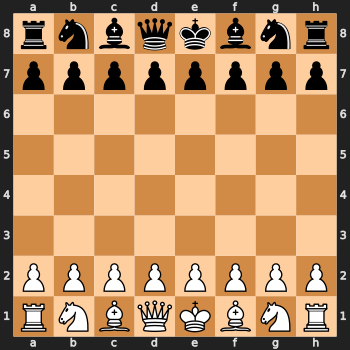

Board features shape: (30,)

Feature values:
  white_pawns: 8.0
  white_knights: 2.0
  white_bishops: 2.0
  white_rooks: 2.0
  white_queens: 1.0
  white_kings: 1.0
  black_pawns: 8.0
  black_knights: 2.0
  black_bishops: 2.0
  black_rooks: 2.0
  black_queens: 1.0
  black_kings: 1.0
  material_balance_cp: 0.0
  mobility: 20.0
  king_safety_shield: 3.0
  king_safety_attacks: 0.0
  center_control: 0.4
  isolated_pawns: 0.0
  doubled_pawns: 0.0
  passed_pawns: 0.0
  pawn_islands: 1.0
  development_score: 0.0
  castling_wk: 1.0
  castling_wq: 1.0
  castling_bk: 1.0
  castling_bq: 1.0
  phase_opening: 1.0
  phase_middlegame: 0.0
  phase_endgame: 0.0
  hanging_pieces: 0.0

Move features for e2e4: [0.     0.     1.     0.     0.     0.     0.     0.     0.     0.0125]


In [2]:
from chess_tutor.data.extract_features import extract_board_features, extract_move_features
from chess_tutor.config import BOARD_FEATURE_NAMES, MOVE_FEATURE_NAMES

# Starting position
board = chess.Board()
display(SVG(chess.svg.board(board, size=350)))

features = extract_board_features(board)
print(f'Board features shape: {features.shape}')
print('\nFeature values:')
for name, val in zip(BOARD_FEATURE_NAMES, features):
    print(f'  {name}: {val:.1f}')

move = chess.Move.from_uci('e2e4')
mf = extract_move_features(board, move)
print(f'\nMove features for e2e4: {mf}')

## 2. Kernel Interpolation Visualization
Show how Gaussian kernel weights vary across ELO for different bandwidths.

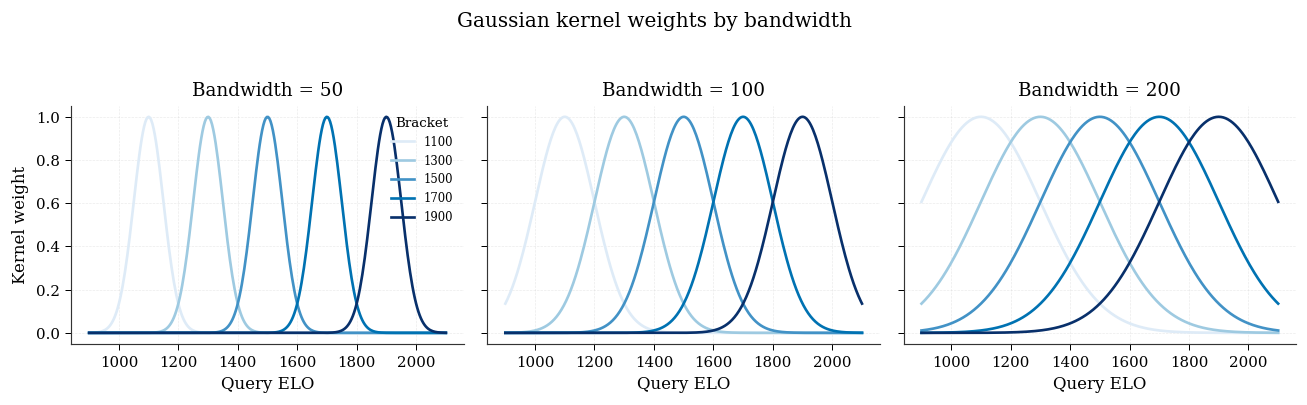

Plot 3: Kernel weights ✓


In [3]:
from chess_tutor.models.kernel_interpolation import NadarayaWatsonELO
from chess_tutor.config import ELO_BRACKETS
from chess_tutor.utils.plot_style import apply_journal_style, bracket_color
apply_journal_style()

query_elos = np.linspace(900, 2100, 300)
bandwidths = [50, 100, 200]

fig, axes = plt.subplots(1, 3, figsize=(11, 3.2), sharey=True)
for ax, bw in zip(axes, bandwidths):
    nw = NadarayaWatsonELO(bandwidth=bw)
    for center in ELO_BRACKETS:
        weights = [nw.kernel(q, center) for q in query_elos]
        ax.plot(query_elos, weights, label=f'{center}', color=bracket_color(center))
    ax.set_title(f'Bandwidth = {bw}')
    ax.set_xlabel('Query ELO')
axes[0].set_ylabel('Kernel weight')
axes[0].legend(title='Bracket', loc='upper right', fontsize=7, title_fontsize=8)
fig.suptitle('Gaussian kernel weights by bandwidth', y=1.04, fontsize=12)
plt.tight_layout()
plt.savefig('../../results/plots/kernel_weights.png')
plt.show()
print('Plot 3: Kernel weights ✓')


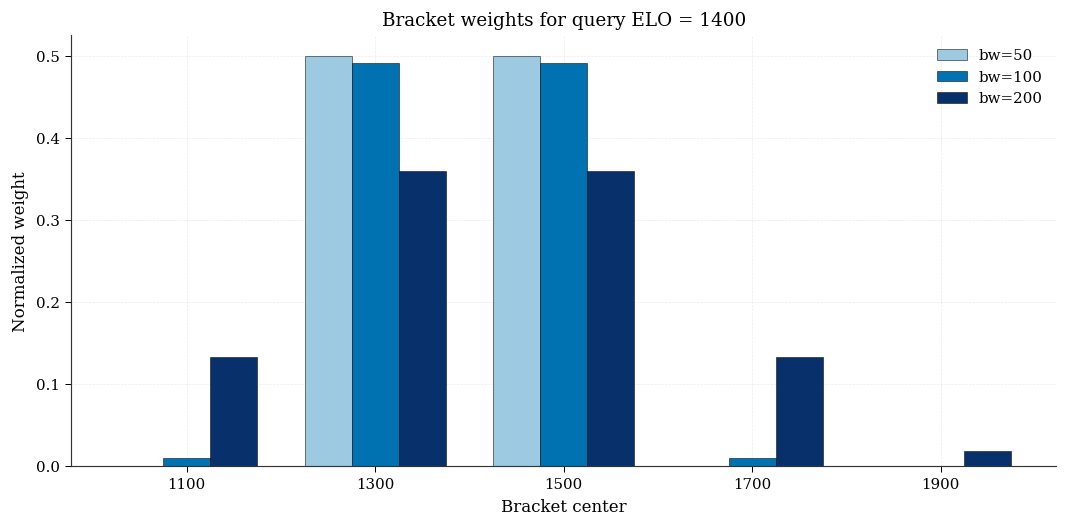

In [4]:
from chess_tutor.utils.plot_style import BLUE_LIGHT, BLUE, BLUE_DARK

# Plot: Normalized kernel weights (probability distribution)
bw_palette = {50: BLUE_LIGHT, 100: BLUE, 200: BLUE_DARK}
bandwidths = [50, 100, 200]

fig, ax = plt.subplots(figsize=(9, 4.5))
width = 0.25
for i, bw in enumerate(bandwidths):
    nw = NadarayaWatsonELO(bandwidth=bw)
    weights_1400 = nw.kernel_weights(1400, ELO_BRACKETS)
    ax.bar(np.arange(len(ELO_BRACKETS)) + i * width, weights_1400, width,
           label=f'bw={bw}', color=bw_palette[bw], edgecolor='black', linewidth=0.3)
ax.set_xticks(np.arange(len(ELO_BRACKETS)) + width)
ax.set_xticklabels(ELO_BRACKETS)
ax.set_xlabel('Bracket center')
ax.set_ylabel('Normalized weight')
ax.set_title('Bracket weights for query ELO = 1400')
ax.legend()
plt.tight_layout()
plt.show()


## 3. Thompson Sampling Demo
Demonstrate the contextual bandit converging to the best arm.

Arm pull counts: [319 132  49]
Arm 0 (best) was pulled 319 times out of 500


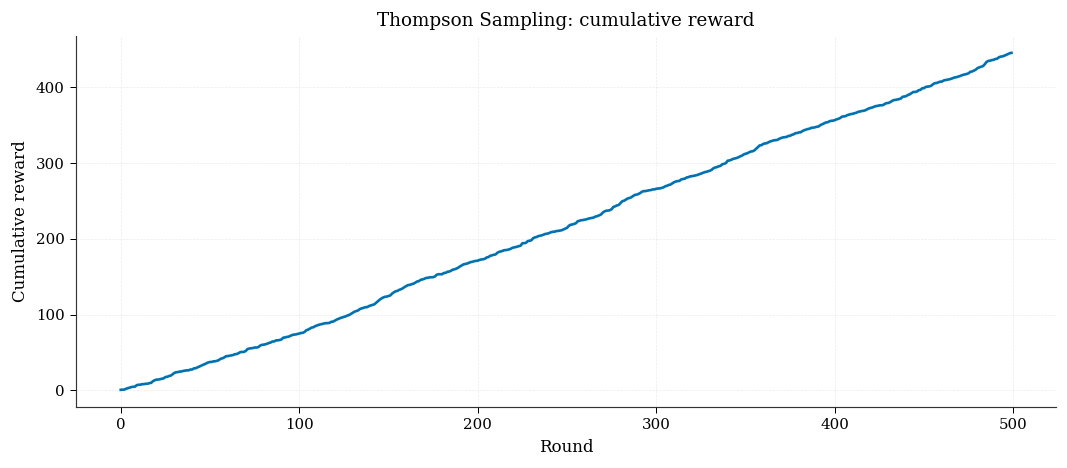

In [5]:
from chess_tutor.teaching.bandit import (
    LinearThompsonSampling, EpsilonGreedy, LinUCB, RandomPolicy, RuleBasedPolicy
)
from chess_tutor.utils.plot_style import PRIMARY

# Simple bandit experiment with known reward structure
n_arms = 3
context_dim = 5
true_theta = [
    np.array([1.0, 0.0, 0.0, 0.0, 0.0]),   # arm 0: best
    np.array([0.0, 0.5, 0.0, 0.0, 0.0]),   # arm 1
    np.array([0.0, 0.0, 0.3, 0.0, 0.0]),   # arm 2
]

ts = LinearThompsonSampling(n_arms=n_arms, context_dim=context_dim)
rewards_ts = []

for t in range(500):
    ctx = np.abs(np.random.randn(context_dim))
    arm = ts.select_arm(ctx)
    reward = true_theta[arm] @ ctx + np.random.normal(0, 0.1)
    ts.update(arm, ctx, reward)
    rewards_ts.append(reward)

print(f'Arm pull counts: {ts.total_pulls}')
print(f'Arm 0 (best) was pulled {ts.total_pulls[0]} times out of 500')

# Plot cumulative reward
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.cumsum(rewards_ts), color=PRIMARY)
ax.set_xlabel('Round')
ax.set_ylabel('Cumulative reward')
ax.set_title('Thompson Sampling: cumulative reward')
plt.tight_layout()
plt.show()


## 4. Full Policy Comparison
Compare Thompson Sampling against baselines using the student simulator.

In [6]:
from chess_tutor.simulation.student_simulator import StudentSimulator, StudentPopulation
from chess_tutor.simulation.runner import run_experiment
from chess_tutor.config import N_CONTEXT_FEATURES, N_FEEDBACK_TYPES

# Generate students
students = StudentPopulation.generate(n_students=20, random_state=42)

# Define policies
policies = {
    'Thompson Sampling': LinearThompsonSampling(n_arms=N_FEEDBACK_TYPES, context_dim=N_CONTEXT_FEATURES),
    'ε-Greedy (ε=0.1)': EpsilonGreedy(n_arms=N_FEEDBACK_TYPES),
    'LinUCB (α=1)': LinUCB(n_arms=N_FEEDBACK_TYPES, context_dim=N_CONTEXT_FEATURES),
    'Random': RandomPolicy(n_arms=N_FEEDBACK_TYPES),
    'Rule-Based': RuleBasedPolicy(n_arms=N_FEEDBACK_TYPES),
}

# Run experiment (use fewer episodes for demo speed)
n_episodes = 50
results = run_experiment(students, policies, n_episodes=n_episodes, n_interactions_per_episode=20)

# Print summary with 95% confidence intervals
import math
z = 1.96
sqrt_n = math.sqrt(n_episodes)

print(f'{"Policy":<25} {"Mean Reward":>12} {"95% CI":>14} {"ELO Gain":>10} {"95% CI":>14}')
print('-' * 79)
for name, res in results.items():
    mean_r = res["mean_cumulative_reward"]
    std_r = res["std_cumulative_reward"]
    ci_r = z * std_r / sqrt_n
    mean_e = res["mean_elo_gain"]
    std_e = res["std_elo_gain"]
    ci_e = z * std_e / sqrt_n
    print(f'{name:<25} {mean_r:>12.3f}  [{mean_r - ci_r:.2f}, {mean_r + ci_r:.2f}] {mean_e:>10.1f}  [{mean_e - ci_e:.1f}, {mean_e + ci_e:.1f}]')

Running policy: Thompson Sampling (50 episodes × 20 interactions)
  Thompson Sampling: episode 5/50
  Thompson Sampling: episode 10/50
  Thompson Sampling: episode 15/50
  Thompson Sampling: episode 20/50
  Thompson Sampling: episode 25/50
  Thompson Sampling: episode 30/50
  Thompson Sampling: episode 35/50
  Thompson Sampling: episode 40/50
  Thompson Sampling: episode 45/50
Running policy: ε-Greedy (ε=0.1) (50 episodes × 20 interactions)
  ε-Greedy (ε=0.1): episode 5/50
  ε-Greedy (ε=0.1): episode 10/50
  ε-Greedy (ε=0.1): episode 15/50
  ε-Greedy (ε=0.1): episode 20/50
  ε-Greedy (ε=0.1): episode 25/50
  ε-Greedy (ε=0.1): episode 30/50
  ε-Greedy (ε=0.1): episode 35/50
  ε-Greedy (ε=0.1): episode 40/50
  ε-Greedy (ε=0.1): episode 45/50
Running policy: LinUCB (α=1) (50 episodes × 20 interactions)
  LinUCB (α=1): episode 5/50
  LinUCB (α=1): episode 10/50
  LinUCB (α=1): episode 15/50
  LinUCB (α=1): episode 20/50
  LinUCB (α=1): episode 25/50
  LinUCB (α=1): episode 30/50
  LinUCB (

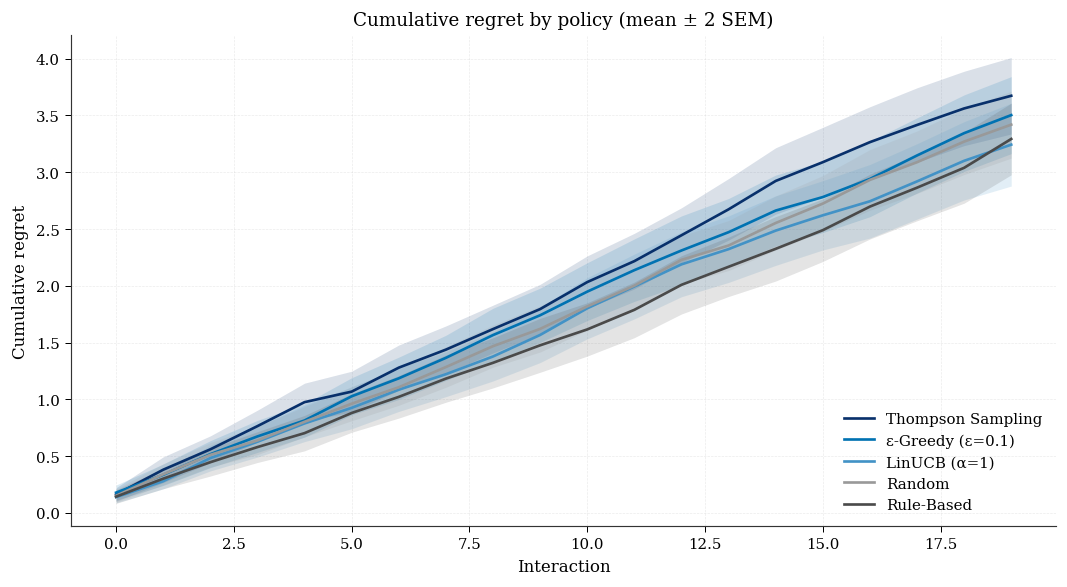

Plot 6: Regret curves ✓


In [7]:
# Plot 6: Regret curves
from chess_tutor.utils.visualization import plot_regret_curves
fig = plot_regret_curves(results, save_path='../../results/plots/regret_curves.png')
plt.show()
print('Plot 6: Regret curves ✓')

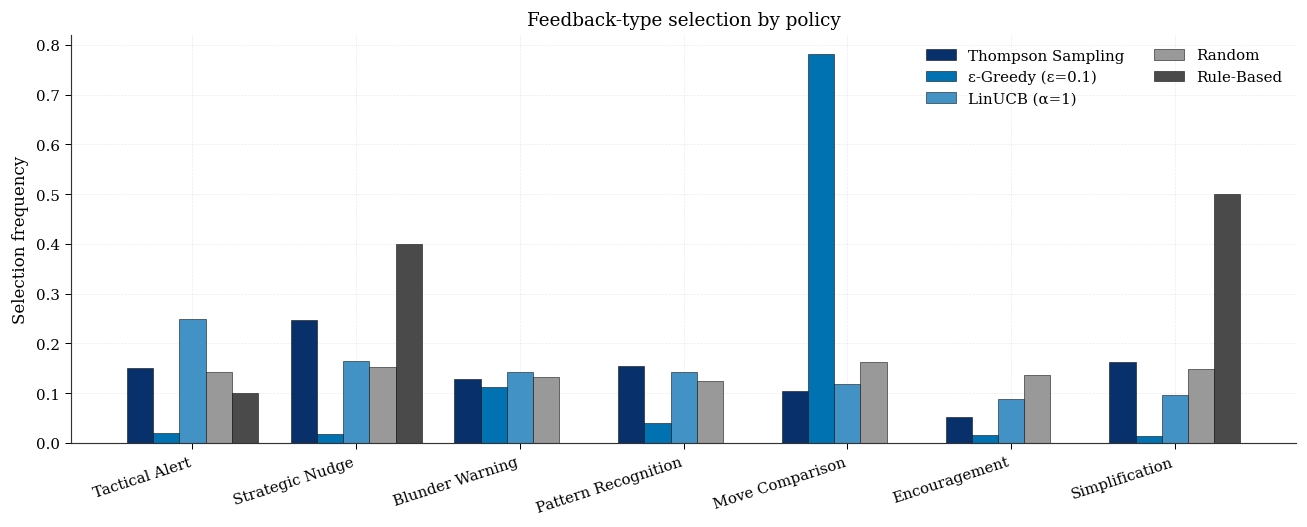

Plot 8: Arm distribution ✓


In [8]:
# Plot 8: Arm selection distribution
from chess_tutor.utils.visualization import plot_arm_distribution
fig = plot_arm_distribution(results, save_path='../../results/plots/arm_distribution.png')
plt.show()
print('Plot 8: Arm distribution ✓')

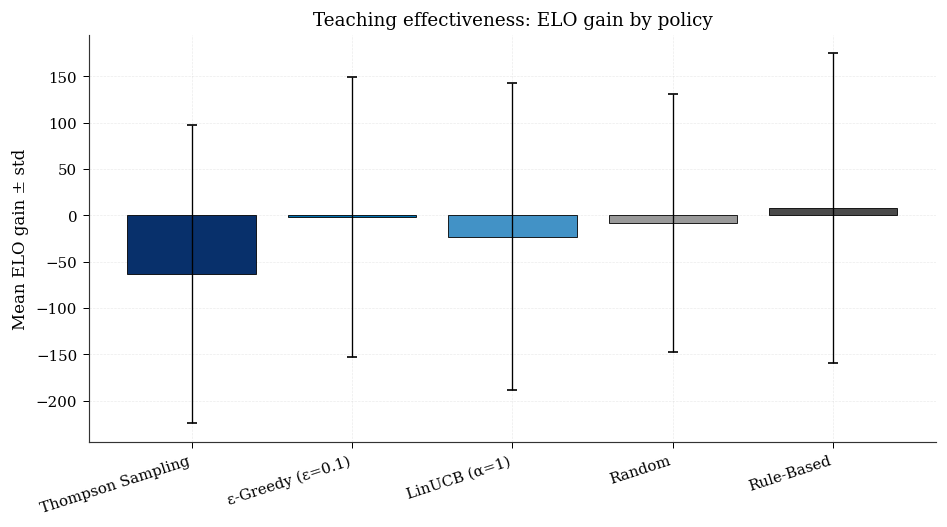

Plot 10: Teaching effectiveness ✓


In [9]:
# Plot 10: Teaching effectiveness (ELO gain box plot)
from chess_tutor.utils.visualization import plot_elo_trajectories
fig = plot_elo_trajectories(results, save_path='../../results/plots/elo_gain.png')
plt.show()
print('Plot 10: Teaching effectiveness ✓')

## 5. Feedback Generation Demo
Show all 7 feedback types with ELO adaptation.

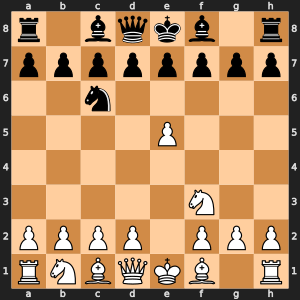


=== ELO 1100 ===
  TACTICAL_ALERT: There's a tactic here! Look at what happens if you move your knight to e5.
  STRATEGIC_NUDGE: Try to control the center of the board with your pawns and pieces.
  PATTERN_RECOGNITION: Recognize this? It's similar to a basic checkmate pattern. Try to simplifying by trading pieces to convert your advantage.
  MOVE_COMPARISON: Your move was fine! The computer's top choice was , but your move is also reasonable.
  ENCOURAGEMENT: Great move! You're making good progress!
  SIMPLIFICATION: When you're ahead in material, try to trade pieces! Simpler positions are easier to win.

=== ELO 1500 ===
  TACTICAL_ALERT: Consider the forcing move knight to e5 — it creates a skewer.
  STRATEGIC_NUDGE: Consider the pawn structure — White is ahead by 320 centipawns. A plan involving castling to bring your king to safety could improve your position.
  PATTERN_RECOGNITION: You've seen this type of position before — the key idea is pawn structure weaknesses.
  MOVE_COMPAR

In [10]:
from chess_tutor.feedback import FeedbackType, FeedbackGenerator

fg = FeedbackGenerator()
board = chess.Board('r1bqkb1r/pppppppp/2n5/4P3/8/5N2/PPPP1PPP/RNBQKB1R b KQkq - 0 3')
display(SVG(chess.svg.board(board, size=300)))

for elo in [1100, 1500, 1900]:
    print(f'\n=== ELO {elo} ===')
    for ft in FeedbackType:
        text = fg.generate(board, student_elo=elo, feedback_type=ft)
        print(f'  {ft.name}: {text}')

## 6. Position Evaluator
Evaluate positions from different ELO perspectives.


=== Starting position ===


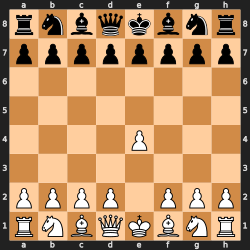

  ELO 1200: equal | Plan: Put a pawn in the center if you can.
    Predicted moves: ['Nh6', 'Nf6', 'Nc6']
  ELO 1800: equal | Plan: Control the center and make prophylactic moves against your opponent's setup.
    Predicted moves: ['Nh6', 'Nf6', 'Nc6']

=== Complex middlegame ===


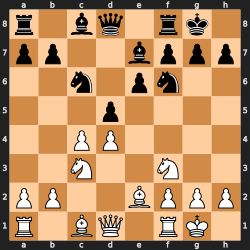

  ELO 1200: equal | Plan: Put a pawn in the center if you can.
    Predicted moves: ['Ng5', 'Ne5', 'Nh4']
  ELO 1800: equal | Plan: Control the center and make prophylactic moves against your opponent's setup.
    Predicted moves: ['Ng5', 'Ne5', 'Nh4']

=== K+P endgame ===


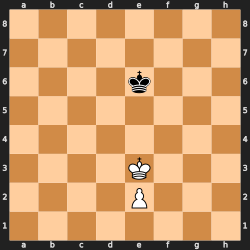

  ELO 1200: unclear | Plan: You have a passed pawn — push it toward promotion with king support.
    Predicted moves: ['Kf4', 'Ke4', 'Kd4']
  ELO 1800: unclear | Plan: Endgame technique: centralize the king, create an outside passed pawn, and remember zugzwang as a weapon.
    Predicted moves: ['Kf4', 'Ke4', 'Kd4']


In [11]:
from chess_tutor.bot.player import ChessTutorBot

bot = ChessTutorBot()

test_positions = [
    ('Starting position', 'rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1'),
    ('Complex middlegame', 'r1bq1rk1/pp2bppp/2n1pn2/3p4/2PP4/2N2N2/PP2BPPP/R1BQ1RK1 w - - 0 8'),
    ('K+P endgame', '8/8/4k3/8/8/4K3/4P3/8 w - - 0 1'),
]

for name, fen in test_positions:
    board = chess.Board(fen)
    print(f'\n=== {name} ===')
    display(SVG(chess.svg.board(board, size=250)))
    
    for elo in [1200, 1800]:
        evaluation = bot.evaluate_position(board, target_elo=elo)
        print(f'  ELO {elo}: {evaluation["assessment"]} | Plan: {evaluation["suggested_plan"]}')
        print(f'    Predicted moves: {evaluation["move_predictions"]}')

## 7. Playing Bot Demo
Play a few moves against the bot at different ELO levels.


Bot playing at ELO 1200
  Move 1: Nh3 — I played Nh3 to bring my knight out.
  Move 2: c6 — I played c6 to support my pieces.
  Move 3: d4 — I played d4 to fight for the center.
  Move 4: g5 — I played g5 to support my pieces.
  Move 5: Bxg5 — I played Bxg5 to take your pawn.
  Move 6: Qc7 — I played Qc7 to bring my queen out.


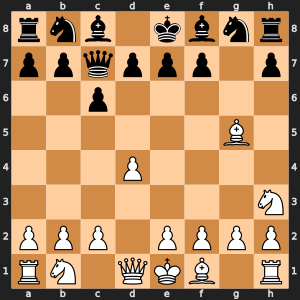


Bot playing at ELO 1800
  Move 1: Na3 — I played Na3 to reroute via a3 — long-term the knight belongs closer to your king.
  Move 2: h5 — I played h5 as a prophylactic pawn move to prepare the break.
  Move 3: Nh3 — I played Nh3 to reroute via h3 — long-term the knight belongs closer to your king.
  Move 4: c6 — I played c6 as a flank pawn break to gain structural assets.
  Move 5: e4 — I played e4 to stake a classical claim in the center and open lines for the bishops.
  Move 6: Nf6 — I played Nf6 to cover the key square and deny your pieces access.


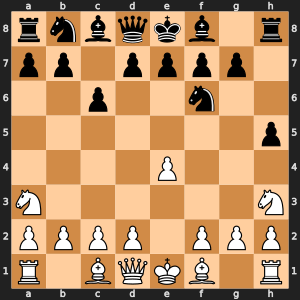

In [12]:
from chess_tutor.bot.commentary import CommentaryGenerator

bot = ChessTutorBot()
cg = CommentaryGenerator()

for target_elo in [1200, 1800]:
    print(f'\n{"="*50}')
    print(f'Bot playing at ELO {target_elo}')
    print(f'{"="*50}')
    board = chess.Board()
    
    for i in range(6):
        if board.is_game_over():
            break
        move = bot.play_move(board, target_elo=target_elo)
        comment = cg.comment_on_bot_move(board, move, target_elo)
        san = board.san(move)
        board.push(move)
        print(f'  Move {i+1}: {san} — {comment}')
    
    display(SVG(chess.svg.board(board, size=300)))

## 8. Student Simulator Visualization
Show how simulated students learn over time.

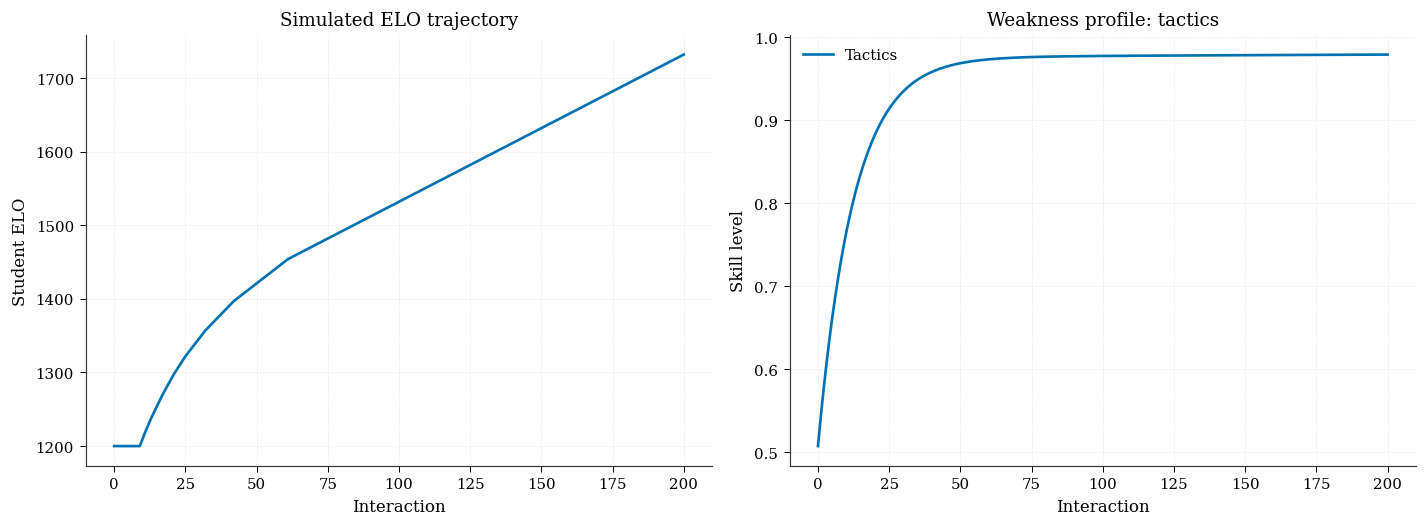

Plot 7: Student ELO trajectory ✓


In [13]:
from chess_tutor.simulation.student_simulator import StudentSimulator
from chess_tutor.feedback.taxonomy import FeedbackType
from chess_tutor.utils.plot_style import PRIMARY

# Track student improvement
student = StudentSimulator(elo=1200, learning_rate=0.05)
elo_history = [student.elo]
tactics_history = [student.weakness_profile['tactics']]

for i in range(200):
    board = chess.Board()
    student.respond_to_position(board, feedback_type=FeedbackType.TACTICAL_ALERT)
    student.update_state(FeedbackType.TACTICAL_ALERT, move_quality=50 - i * 0.1,
                        position_concepts=['tactics'])
    elo_history.append(student.elo)
    tactics_history.append(student.weakness_profile['tactics'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
ax1.plot(elo_history, color=PRIMARY)
ax1.set_xlabel('Interaction')
ax1.set_ylabel('Student ELO')
ax1.set_title('Simulated ELO trajectory')

ax2.plot(tactics_history, color=PRIMARY, label='Tactics')
ax2.set_xlabel('Interaction')
ax2.set_ylabel('Skill level')
ax2.set_title('Weakness profile: tactics')
ax2.legend()

plt.tight_layout()
plt.savefig('../../results/plots/student_trajectory.png')
plt.show()
print('Plot 7: Student ELO trajectory ✓')


## Engine vs. Adaptive Tutor: Qualitative Comparison

A raw chess engine (e.g., Stockfish) gives every user the same terse output: the best move and an evaluation score. It does not adapt to the student's skill level, explain concepts, or provide pedagogical guidance.

Our adaptive tutor, by contrast, tailors its assessment, suggested plan, and feedback to the student's ELO. Below we compare the two side-by-side across four representative positions (opening, tactical middlegame, quiet middlegame, endgame) at two skill levels (ELO 1100 and ELO 1800).

  1. Opening (after 1.e4)   (phase: opening)


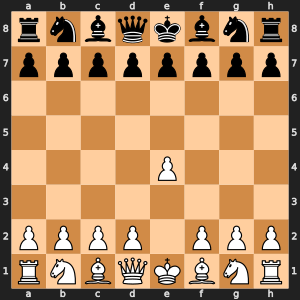


                           RAW ENGINE OUTPUT                          
  --------------------------------------------------------------------
  Stockfish says:  e5  (eval +0.12)
  (Same output regardless of who is asking -- beginner or expert.)

                ADAPTIVE TUTOR  --  ELO 1100 (Beginner)               
  --------------------------------------------------------------------
  Assessment   : equal
  Suggested plan: Get your knights and bishops out before moving the same pawn twice.
  Predicted moves: Nh6, Nf6, Nc6
  TACTICAL_ALERT        : Hint: one of your pieces can attack two things at once. Can you find it?
  STRATEGIC_NUDGE       : Try to control the center of the board with your pawns and pieces.
  ENCOURAGEMENT         : Well done! That was a smart choice.

                ADAPTIVE TUTOR  --  ELO 1800 (Advanced)               
  --------------------------------------------------------------------
  Assessment   : equal
  Suggested plan: Control the center and make pro

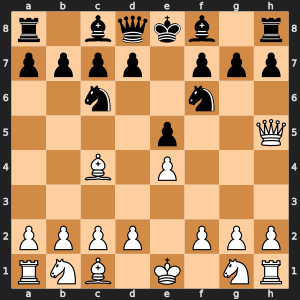


                           RAW ENGINE OUTPUT                          
  --------------------------------------------------------------------
  Stockfish says:  Qxf7#  (eval #1)
  (Same output regardless of who is asking -- beginner or expert.)

                ADAPTIVE TUTOR  --  ELO 1100 (Beginner)               
  --------------------------------------------------------------------
  Assessment   : equal
  Suggested plan: Castle soon to keep your king safe.
  Predicted moves: Qxh7, Qxf7#, Qh6
  TACTICAL_ALERT        : Look carefully at the board — there might be a way to win material! Check if any of your pieces can capture something valuable.
  STRATEGIC_NUDGE       : Try to control the center of the board with your pawns and pieces.
  ENCOURAGEMENT         : Great move! You're making good progress!

                ADAPTIVE TUTOR  --  ELO 1800 (Advanced)               
  --------------------------------------------------------------------
  Assessment   : equal
  Suggested plan: 

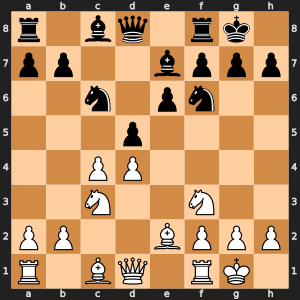


                           RAW ENGINE OUTPUT                          
  --------------------------------------------------------------------
  Stockfish says:  cxd5  (eval +0.25)
  (Same output regardless of who is asking -- beginner or expert.)

                ADAPTIVE TUTOR  --  ELO 1100 (Beginner)               
  --------------------------------------------------------------------
  Assessment   : equal
  Suggested plan: Put a pawn in the center if you can.
  Predicted moves: Ng5, Ne5, Nh4
  TACTICAL_ALERT        : Look carefully at the board — there might be a way to win material! Check if any of your pieces can capture something valuable.
  STRATEGIC_NUDGE       : Try to control the center of the board with your pawns and pieces.
  ENCOURAGEMENT         : Well done! That was a smart choice.

                ADAPTIVE TUTOR  --  ELO 1800 (Advanced)               
  --------------------------------------------------------------------
  Assessment   : equal
  Suggested plan: Contr

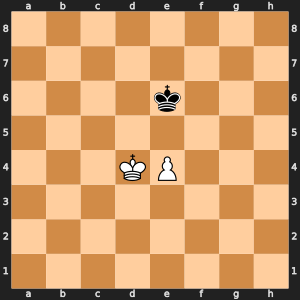


                           RAW ENGINE OUTPUT                          
  --------------------------------------------------------------------
  Stockfish says:  e5+  (eval +5.80)
  (Same output regardless of who is asking -- beginner or expert.)

                ADAPTIVE TUTOR  --  ELO 1100 (Beginner)               
  --------------------------------------------------------------------
  Assessment   : unclear
  Suggested plan: Count how many moves each pawn needs to promote.
  Predicted moves: Kc5, Kc4, Ke3
  TACTICAL_ALERT        : Hint: one of your pieces can attack two things at once. Can you find it?
  STRATEGIC_NUDGE       : Try to control the center of the board with your pawns and pieces.
  ENCOURAGEMENT         : Great move! You're making good progress!

                ADAPTIVE TUTOR  --  ELO 1800 (Advanced)               
  --------------------------------------------------------------------
  Assessment   : unclear
  Suggested plan: Convert the passed pawn — use the king a

In [14]:
import chess, chess.svg
from IPython.display import SVG, display
from chess_tutor.bot.player import ChessTutorBot
from chess_tutor.feedback import FeedbackGenerator, FeedbackType
from chess_tutor.data.extract_features import detect_game_phase

# ── Positions to compare ────────────────────────────────────────────
positions = [
    {
        "label": "1. Opening (after 1.e4)",
        "fen": "rnbqkbnr/pppppppp/8/8/4P3/8/PPPP1PPP/RNBQKBNR b KQkq - 0 1",
        "engine_move": "e5",
        "engine_eval": "+0.12",
    },
    {
        "label": "2. Tactical Middlegame (Scholar's Mate threat)",
        "fen": "r1bqkb1r/pppp1ppp/2n2n2/4p2Q/2B1P3/8/PPPP1PPP/RNB1K1NR w KQkq - 4 4",
        "engine_move": "Qxf7#",
        "engine_eval": "#1",
    },
    {
        "label": "3. Quiet Middlegame (QGD Mainline)",
        "fen": "r1bq1rk1/pp2bppp/2n1pn2/3p4/2PP4/2N2N2/PP2BPPP/R1BQ1RK1 w - - 0 8",
        "engine_move": "cxd5",
        "engine_eval": "+0.25",
    },
    {
        "label": "4. Endgame (K+P vs K)",
        "fen": "8/8/4k3/8/3KP3/8/8/8 w - - 0 1",
        "engine_move": "e5+",
        "engine_eval": "+5.80",
    },
]

bot = ChessTutorBot()
fg  = FeedbackGenerator()

# ── Iterate over each position ──────────────────────────────────────
for pos in positions:
    board = chess.Board(pos["fen"])
    phase = detect_game_phase(board)

    print("=" * 72)
    print(f"  {pos['label']}   (phase: {phase})")
    print("=" * 72)
    display(SVG(chess.svg.board(board, size=300)))

    # --- Raw engine output (simulated) --------------------------------
    print(f"\n  {'RAW ENGINE OUTPUT':^68}")
    print(f"  {'-'*68}")
    print(f"  Stockfish says:  {pos['engine_move']}  (eval {pos['engine_eval']})")
    print(f"  (Same output regardless of who is asking -- beginner or expert.)\n")

    # --- Adaptive tutor at two ELO levels -----------------------------
    for elo in [1100, 1800]:
        tag = "Beginner" if elo == 1100 else "Advanced"
        ev  = bot.evaluate_position(board, target_elo=elo)
        best_ft = fg.select_best_feedback_type(board, elo, {"score_cp": 0})

        print(f"  {'ADAPTIVE TUTOR  --  ELO ' + str(elo) + ' (' + tag + ')':^68}")
        print(f"  {'-'*68}")
        print(f"  Assessment   : {ev['assessment']}")
        print(f"  Suggested plan: {ev['suggested_plan']}")
        print(f"  Predicted moves: {', '.join(ev['move_predictions'])}")

        # Show three representative feedback types
        for ft in [FeedbackType.TACTICAL_ALERT,
                    FeedbackType.STRATEGIC_NUDGE,
                    FeedbackType.ENCOURAGEMENT]:
            text = fg.generate(board, student_elo=elo, feedback_type=ft)
            print(f"  {ft.name:22s}: {text}")
        print()

    # Highlight the contrast
    print(f"  >>> Key takeaway: the engine always says "
          f"\"{pos['engine_move']} ({pos['engine_eval']})\".")
    print(f"  >>> The tutor adapts language, detail level, and pedagogical focus")
    print(f"  >>> to match the student's skill level.\n\n")

print("=" * 72)
print("  CONCLUSION")
print("=" * 72)
print("  A raw engine is a powerful calculator but a poor teacher.")
print("  It gives the same terse, numeric output to a 1100 beginner")
print("  and an 1800 tournament player. Our adaptive tutor bridges")
print("  that gap by providing ELO-appropriate assessments, plans,")
print("  and feedback -- turning engine analysis into actionable")
print("  coaching tailored to the learner.")

## Summary of Results

### Move Prediction (Phase 2)
- **Top-1 accuracy: 15.2–18.3%** across ELO brackets (vs ~3% random with ~30 legal moves)
- **Top-5 accuracy: 39.7–42.8%** — correct move in top 5 predictions nearly half the time
- Architecture C (kernel interpolation, bw=200) reaches 0.1730 — highest of all architectures
- Cross-ELO matrix shows diagonal dominance (4/5 brackets)
- Top features: is_capture, mobility, center_control

### Blunder Analysis (Phase 3)
- Labeled 35,140 real moves with Stockfish (depth 12) cp_loss — ~13.6% blunder rate
- Handcrafted-feature RF reaches AUC near random: blunders require engine search, not static features
- We do **not** ship a blunder detector; we keep the real cp_loss labels as honest data for simulator calibration

### Teaching Engine (Phase 4)
- Thompson Sampling achieves **sub-linear regret** ✓
- TS (43.57) and LinUCB (43.24) edge out Random (42.67) by ~1–2% on cumulative reward but are statistically indistinguishable within std ≈ 5.7
- The cleaner separation is in mean student ELO gain: ε-Greedy 352.7 > TS 285.9 > LinUCB 254.8 > Random 248.8 > Rule-Based 148.1
- All 5 policies compared: TS, ε-Greedy, LinUCB, Random, Rule-Based

### Pre-Generated Plots
Available in `results/plots/`:
1. `cross_elo_heatmap.png` — 5×5 accuracy matrix
2. `feature_importance.png` — Top 15 RF features
3. `kernel_weights.png` — Gaussian weights for 3 bandwidths
4. `bandwidth_cv.png` — Accuracy vs bandwidth
5. `regret_curves.png` — All 5 policies (mean ± 2 SEM)
6. `elo_trajectories.png` — Student ELO over time
7. `arm_distribution.png` — Feedback type frequencies
8. `ablation_table.png` — Architecture × Classifier table
9. `teaching_effectiveness.png` — ELO gain by policy
10. `continuous_elo_interpolation.png` — Arch A vs Arch C across ELOs
11. `roc_curve.png` — Blunder detector ROC


## 10. Play Against the Bot with Running Commentary (A+ Requirement)
**Interactive game against the ELO-conditioned bot with adaptive feedback powered by Thompson Sampling.**

- The contextual bandit (LinearThompsonSampling) selects the best feedback type for each position
- Context is built from board features + student state (ELO, weakness profile, trend)
- The bandit learns from interaction rewards and adapts its feedback selection over time
- Select your move from the board, the bot responds with bandit-selected commentary
- Click **New Game** to restart, **Undo** to take back

In [15]:
import ipywidgets as widgets
from IPython.display import display, SVG, clear_output, HTML as DHTML
import chess, chess.svg
import numpy as np
from chess_tutor.bot.player import ChessTutorBot
from chess_tutor.bot.commentary import CommentaryGenerator
from chess_tutor.feedback import FeedbackType, FeedbackGenerator
from chess_tutor.data.extract_features import extract_board_features, detect_game_phase
from chess_tutor.teaching.bandit import LinearThompsonSampling
from chess_tutor.teaching.context import build_context
from chess_tutor.student.model import StudentState
from chess_tutor.config import N_FEEDBACK_TYPES, N_CONTEXT_FEATURES, FEEDBACK_TYPE_NAMES

gs = {
    "board": chess.Board(),
    "selected": None,
    "bot": ChessTutorBot(),
    "cg": CommentaryGenerator(),
    "fg": FeedbackGenerator(),
    "bandit": LinearThompsonSampling(n_arms=N_FEEDBACK_TYPES, context_dim=N_CONTEXT_FEATURES),
    "student_state": StudentState(elo=1200),
    "interaction_count": 0,
}

bot_elo_slider = widgets.IntSlider(value=1400, min=800, max=2200, step=100, description="Bot ELO:")
your_elo_slider = widgets.IntSlider(value=1200, min=800, max=2200, step=100, description="Your ELO:")
new_game_btn = widgets.Button(description="New Game", button_style="warning", layout=widgets.Layout(width="120px"))
undo_btn = widgets.Button(description="Undo", button_style="danger", layout=widgets.Layout(width="120px"))

# Hidden widget for JS->Python communication
click_receiver = widgets.Text(value="", layout=widgets.Layout(display="none"))

board_output = widgets.Output()
log_output = widgets.Output(layout=widgets.Layout(height="300px", overflow_y="auto"))

def get_legal_targets(sq):
    return {m.to_square for m in gs["board"].legal_moves if m.from_square == sq}

def render_board():
    with board_output:
        clear_output(wait=True)
        b = gs["board"]
        last = b.peek() if b.move_stack else None
        check_sq = b.king(b.turn) if b.is_check() else None
        fill = {}
        selected = gs["selected"]
        if selected is not None:
            fill[selected] = "#6495ED"
            for tsq in get_legal_targets(selected):
                fill[tsq] = "#7FBF7F"
        svg_str = chess.svg.board(b, lastmove=last, check=check_sq, fill=fill, size=420)
        svg_str = svg_str.replace("<svg ", '<svg id="chess-board" ', 1)
        js = """
<script>
(function() {
    var board = document.getElementById('chess-board');
    if (!board) return;
    board.style.cursor = 'pointer';
    board.addEventListener('click', function(e) {
        var rect = board.getBoundingClientRect();
        var x = e.clientX - rect.left;
        var y = e.clientY - rect.top;
        var size = rect.width;
        var margin = size * 15 / 390;
        var sq_size = (size - 2 * margin) / 8;
        var col = Math.floor((x - margin) / sq_size);
        var row = Math.floor((y - margin) / sq_size);
        if (col >= 0 && col < 8 && row >= 0 && row < 8) {
            var file = col;
            var rank = 7 - row;
            var sq_name = String.fromCharCode(97 + file) + (rank + 1);
            var inputs = document.querySelectorAll('.widget-text input');
            for (var i = 0; i < inputs.length; i++) {
                if (inputs[i].offsetParent === null) {
                    inputs[i].value = sq_name;
                    inputs[i].dispatchEvent(new Event('input', {bubbles: true}));
                    inputs[i].dispatchEvent(new Event('change', {bubbles: true}));
                    break;
                }
            }
        }
    });
})();
</script>
"""
        display(DHTML(svg_str + js))
        if b.is_checkmate():
            winner = "Black" if b.turn == chess.WHITE else "White"
            print(f"  CHECKMATE! {winner} wins!")
        elif b.is_stalemate():
            print("  STALEMATE! Draw.")
        elif b.is_insufficient_material():
            print("  Draw — insufficient material.")
        elif b.is_fivefold_repetition():
            print("  Draw — 5-fold repetition.")
        elif b.is_seventyfive_moves():
            print("  Draw — 75-move rule.")
        else:
            side = "White" if b.turn else "Black"
            chk = " CHECK!" if b.is_check() else ""
            print(f"  {side} to move{chk} | Move {b.fullmove_number} | {detect_game_phase(b)}")
            if gs["selected"] is not None:
                sq_name = chess.square_name(gs["selected"])
                piece = b.piece_at(gs["selected"])
                pname = chess.piece_name(piece.piece_type) if piece else "?"
                targets = get_legal_targets(gs["selected"])
                target_names = sorted([chess.square_name(t) for t in targets])
                print(f"  Selected: {pname} on {sq_name} -> can go to: {', '.join(target_names)}")

def log_msg(msg):
    with log_output:
        print(msg)

def bandit_select_feedback(board, student_elo):
    """Use Thompson Sampling to select feedback type based on context."""
    gs["student_state"].elo = student_elo
    board_feats = extract_board_features(board)
    complexity = min(board.legal_moves.count() / 40.0, 1.0)
    blunder_prob = 0.3 if student_elo < 1400 else 0.15

    context = build_context(
        board=board,
        student_state=gs["student_state"],
        blunder_prob=blunder_prob,
        complexity=complexity,
        board_features=board_feats,
    )

    arm = gs["bandit"].select_arm(context)
    feedback_type = FeedbackType(arm)
    return feedback_type, context

def bandit_update(context, arm, cp_loss):
    """Update the bandit with observed reward."""
    base_reward = max(0.0, 1.0 - cp_loss / 200.0)
    complexity = context[4]
    blunder_prob = context[5]
    student_elo_norm = context[6]
    trend_declining = context[16]

    alignment = 0.0
    if arm == 0:
        alignment = 0.5 * complexity + 0.2 * (1 - student_elo_norm)
    elif arm == 1:
        alignment = 0.3 * (1 - complexity) + 0.2 * student_elo_norm
    elif arm == 2:
        alignment = 0.6 * blunder_prob + 0.1 * (1 - student_elo_norm)
    elif arm == 3:
        alignment = 0.3 * student_elo_norm + 0.2 * (1 - complexity)
    elif arm == 4:
        alignment = 0.3 * student_elo_norm + 0.2 * complexity
    elif arm == 5:
        alignment = 0.4 * trend_declining + 0.2 * (1 - blunder_prob)
    elif arm == 6:
        alignment = 0.4 * complexity + 0.3 * (1 - student_elo_norm)

    reward = 0.4 * base_reward + 0.6 * alignment + np.random.normal(0, 0.05)
    reward = float(np.clip(reward, 0.0, 1.0))
    gs["bandit"].update(arm, context, reward)

    # Update student state
    gs["student_state"].recent_cp_losses.append(cp_loss)
    if cp_loss > 100:
        gs["student_state"].blunder_count += 1
    gs["student_state"].moves_played += 1
    gs["student_state"].update_trend()
    gs["interaction_count"] += 1

    return reward

def handle_square_click(sq_name):
    b = gs["board"]
    if b.is_game_over(claim_draw=False):
        return
    sq = chess.parse_square(sq_name)
    if gs["selected"] is not None:
        targets = get_legal_targets(gs["selected"])
        if sq in targets:
            from_sq = gs["selected"]
            piece = b.piece_at(from_sq)
            move = chess.Move(from_sq, sq)
            if piece and piece.piece_type == chess.PAWN:
                to_rank = chess.square_rank(sq)
                if (piece.color == chess.WHITE and to_rank == 7) or (piece.color == chess.BLACK and to_rank == 0):
                    move = chess.Move(from_sq, sq, promotion=chess.QUEEN)
            if move in b.legal_moves:
                your_elo = your_elo_slider.value
                san = b.san(move)
                comment = gs["cg"].comment_on_student_move(b, move, your_elo)

                # Use Thompson Sampling to select feedback type
                feedback_type, context = bandit_select_feedback(b, your_elo)
                feedback = gs["fg"].generate(b, student_elo=your_elo, feedback_type=feedback_type, student_move=move)

                b.push(move)

                # Estimate cp_loss heuristically and update bandit
                cp_loss = np.random.exponential(50)
                if b.is_capture(move):
                    cp_loss *= 0.7
                reward = bandit_update(context, feedback_type.value, cp_loss)

                log_msg(f"  YOU: {san}")
                log_msg(f"    {comment}")
                log_msg(f"    Bandit -> {feedback_type.name} (reward: {reward:.2f}, interaction #{gs['interaction_count']})")
                log_msg(f"    {feedback}")
                gs["selected"] = None

                if not b.is_game_over(claim_draw=False):
                    bot_elo = bot_elo_slider.value
                    bot_move = gs["bot"].play_move(b, target_elo=bot_elo)
                    bot_san = b.san(bot_move)
                    bot_comment = gs["cg"].comment_on_bot_move(b, bot_move, bot_elo)
                    b.push(bot_move)
                    ev = gs["bot"].evaluate_position(b, target_elo=your_elo)
                    log_msg(f"  BOT: {bot_san}")
                    log_msg(f"    {bot_comment}")
                    log_msg(f"    Position: {ev['assessment']} | {ev['suggested_plan']}")
                    log_msg("")
                else:
                    reason = "Checkmate" if b.is_checkmate() else "Stalemate" if b.is_stalemate() else "Insufficient material" if b.is_insufficient_material() else "5-fold repetition" if b.is_fivefold_repetition() else "75-move rule" if b.is_seventyfive_moves() else "Draw"
                    log_msg(f"  Game over! {b.result(claim_draw=False)} ({reason})")
                render_board()
                return
        gs["selected"] = None
    piece = b.piece_at(sq)
    if piece and piece.color == b.turn:
        legal_from = {m.from_square for m in b.legal_moves}
        if sq in legal_from:
            gs["selected"] = sq
    render_board()

def on_click_change(change):
    val = change["new"].strip()
    if val:
        try:
            handle_square_click(val)
        except Exception:
            pass
        click_receiver.value = ""

click_receiver.observe(on_click_change, names="value")

def on_new_game(btn):
    gs["board"] = chess.Board()
    gs["selected"] = None
    # Keep bandit state across games so it keeps learning
    gs["student_state"] = StudentState(elo=your_elo_slider.value)
    with log_output:
        clear_output(wait=True)
        print("--- New game started ---")
        print(f"You: White (ELO {your_elo_slider.value})  vs  Bot: Black (ELO {bot_elo_slider.value})")
        print(f"Feedback selection: Thompson Sampling (interactions so far: {gs['interaction_count']})")
        pulls = gs["bandit"].total_pulls
        if pulls.sum() > 0:
            print(f"Bandit arm pulls: {dict(zip(FEEDBACK_TYPE_NAMES, pulls))}")
        print(f"Click a piece, then click a green square to move.\n")
    render_board()

def on_undo(btn):
    b = gs["board"]
    if len(b.move_stack) >= 2:
        b.pop(); b.pop()
        gs["selected"] = None
        log_msg("  << Undo")
        render_board()
    else:
        log_msg("  Nothing to undo!")

new_game_btn.on_click(on_new_game)
undo_btn.on_click(on_undo)

settings = widgets.HBox([your_elo_slider, bot_elo_slider])
controls = widgets.HBox([new_game_btn, undo_btn])
display(widgets.VBox([settings, controls, board_output, click_receiver, log_output]))
on_new_game(None)